## PR2610: Analiza dirk Formule 1
### Projektna naloga pri predmetu Podatkovno Rudarjenje

In [ ]:
# pip install fastf1
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import matplotlib.colors as mcolors
import warnings

warnings.filterwarnings('ignore')

In [2]:
fastf1.Cache.enable_cache('./cache')
# plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

## Tyre degradation

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for dr


Skupaj krogov: 19085
Spojine: ['HARD' 'MEDIUM' 'SOFT' 'INTERMEDIATE' 'None' 'WET']


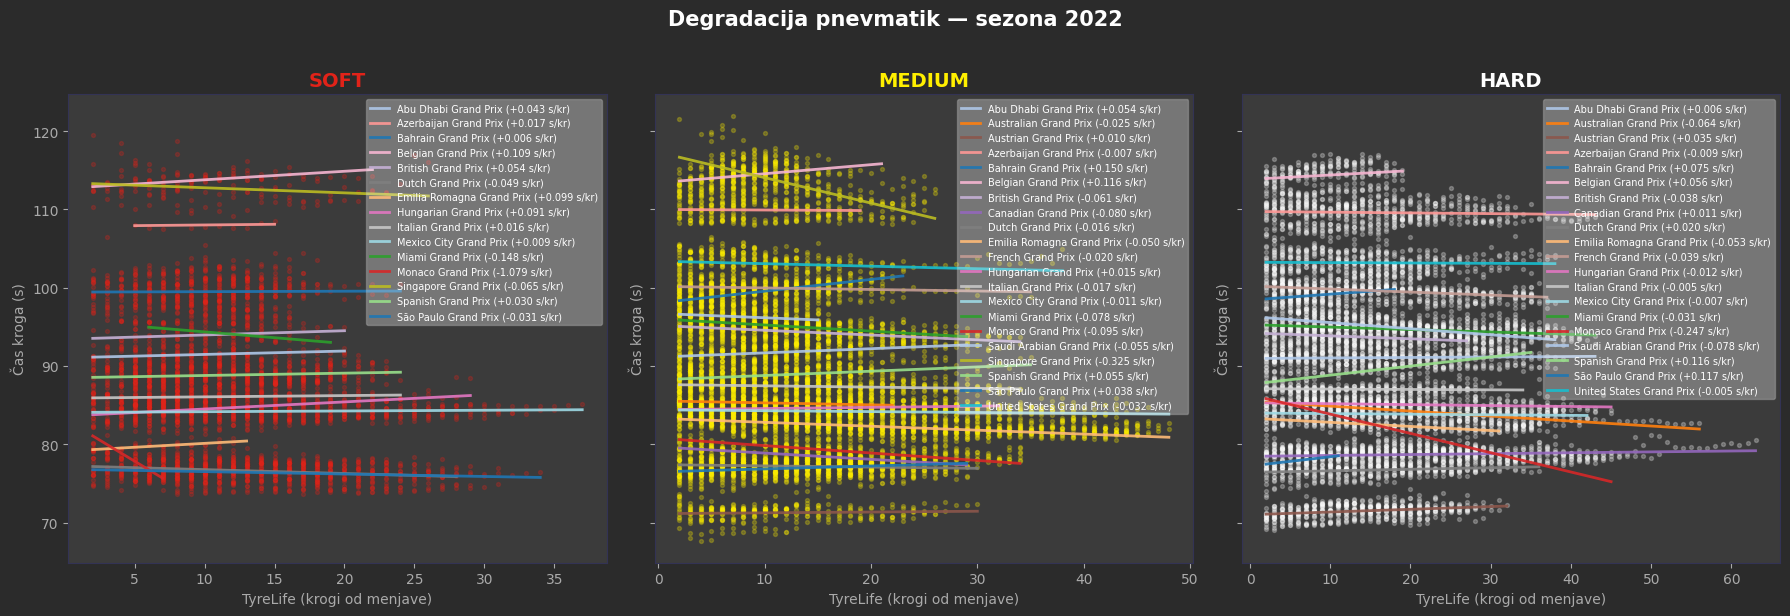

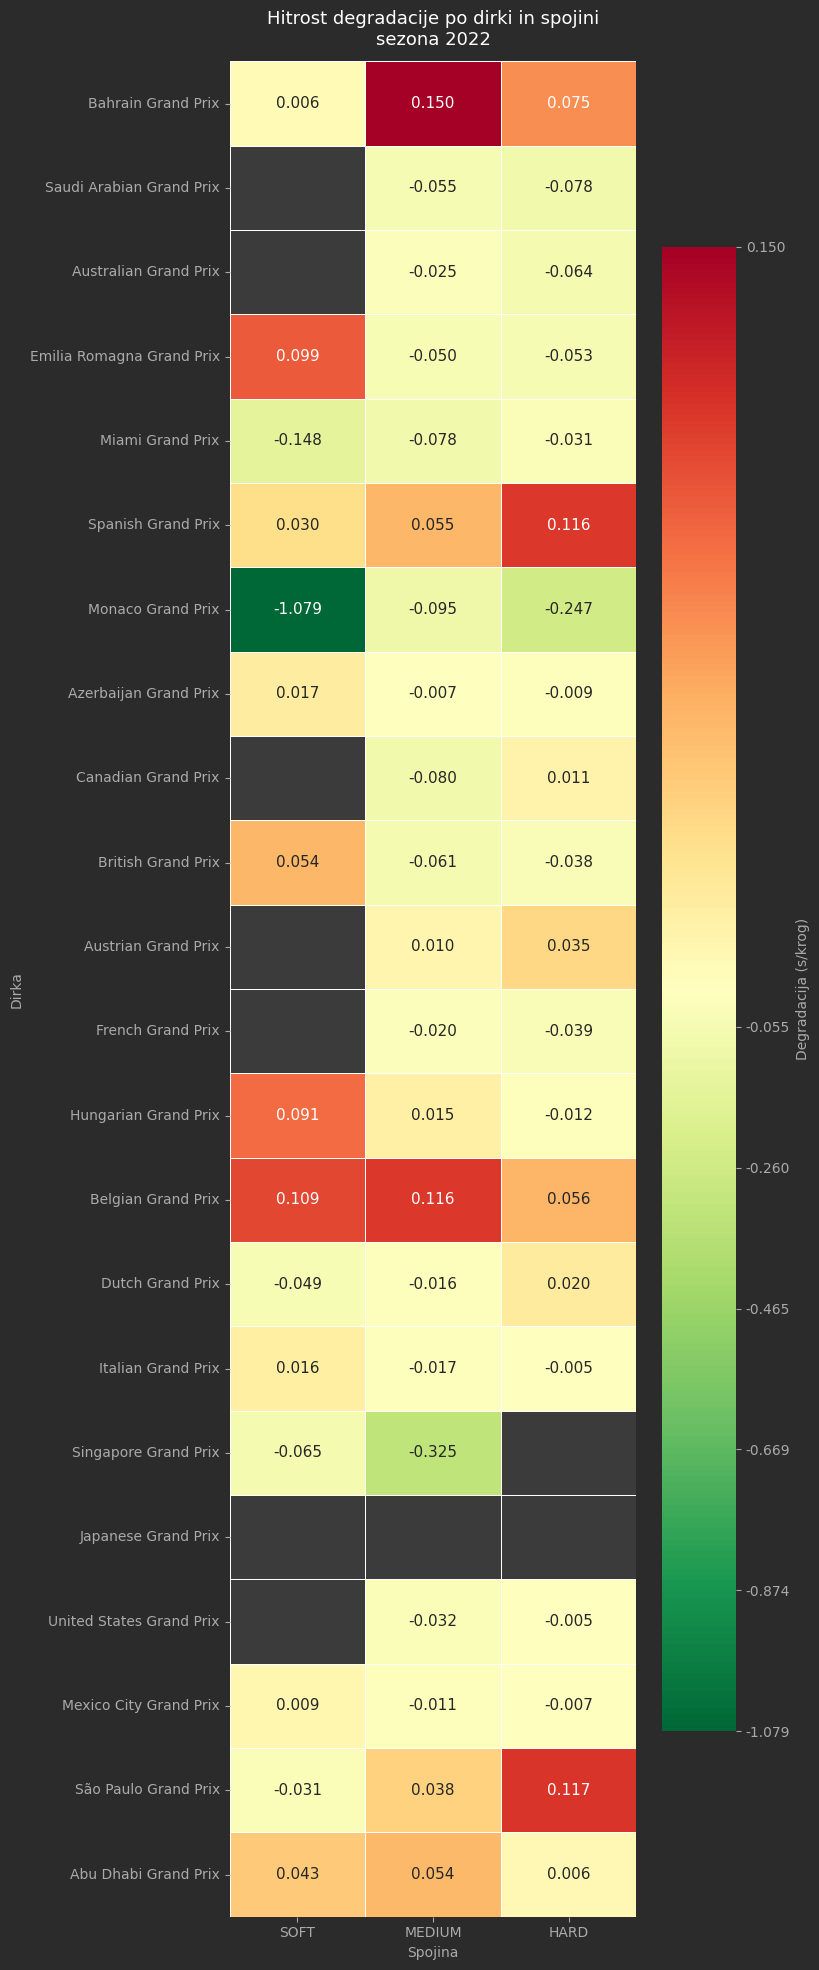

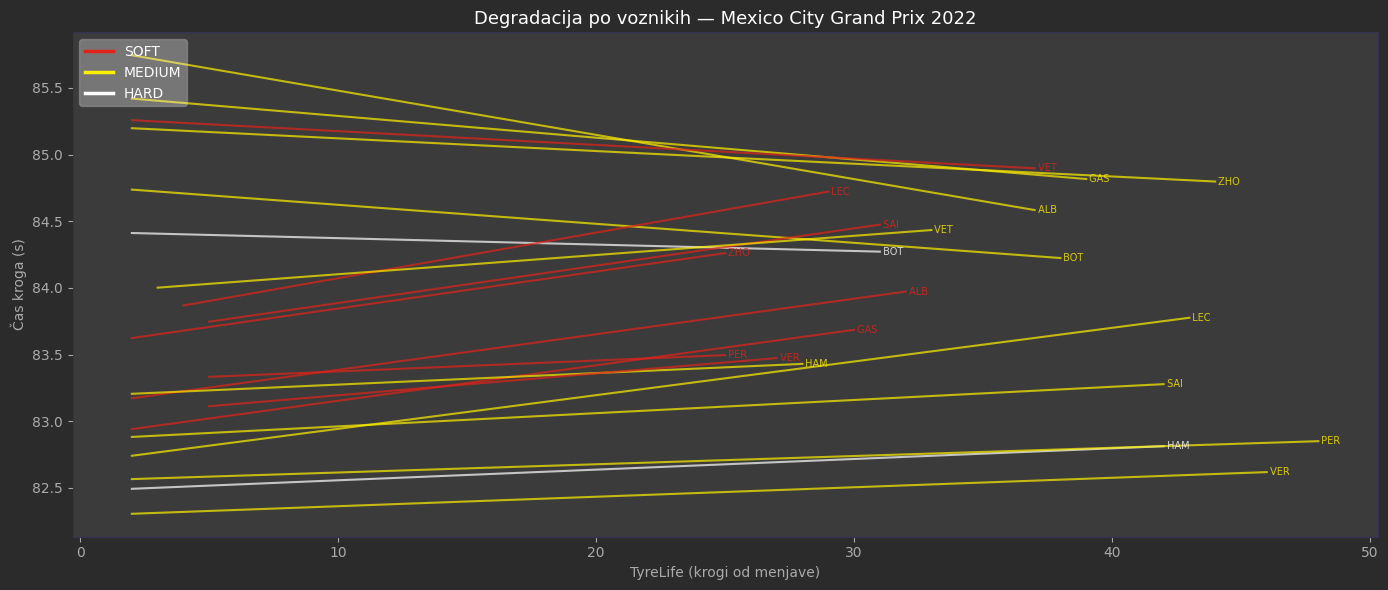

Povprečna degradacija po spojini (s/krog)
            mean     std     min     max
Compound                                
HARD     -0.0075  0.0776 -0.2465  0.1174
MEDIUM   -0.0207  0.0933 -0.3252  0.1502
SOFT     -0.0599  0.2900 -1.0793  0.1090

Najhitrejša degradacija po dirki
                     Race Compound  Slope_s_per_lap
     Abu Dhabi Grand Prix   MEDIUM         0.053503
    Australian Grand Prix   MEDIUM        -0.025264
      Austrian Grand Prix     HARD         0.034611
    Azerbaijan Grand Prix     SOFT         0.017218
       Bahrain Grand Prix   MEDIUM         0.150201
       Belgian Grand Prix   MEDIUM         0.115988
       British Grand Prix     SOFT         0.054110
      Canadian Grand Prix     HARD         0.011349
         Dutch Grand Prix     HARD         0.019772
Emilia Romagna Grand Prix     SOFT         0.099488
        French Grand Prix   MEDIUM        -0.019864
     Hungarian Grand Prix     SOFT         0.090725
       Italian Grand Prix     SOFT         

In [4]:
# Nastavitve

# Sezona
SEASON = 2022
# Dirke
# RACES = ['Japan', 'Monza', 'Australia', 'Mexico']
schedule = fastf1.get_event_schedule(SEASON)
num_races = schedule['RoundNumber'].max()
RACES = range(1, num_races + 1)

race_names = [
    schedule[schedule['RoundNumber'] == r]['EventName'].values[0]
    for r in RACES
]

RACES = race_names

DRIVERS = None  # None = vsi
COMPOUND_COLORS = {
    'SOFT':   '#E12319',
    'MEDIUM': '#FFEF00',
    'HARD':   '#FFFFFF',
    'INTER':  '#39B54A',
    'WET':    '#0067FF',
}
MIN_LAPS_FOR_FIT = 5    # najmanjše število krogov za regresijsko premico

COLORS = plt.cm.tab20.colors  # ali 'tab20' za več dirk 'tab10' za manj
RACE_COLORS = {race: COLORS[i % len(COLORS)] for i, race in enumerate(RACES)}

# Funkcije
def load_race_laps(season: int, race_name: str) -> pd.DataFrame:
    """Naloži in filtrira kroge ene dirke"""
    session = fastf1.get_session(season, race_name, 'R')
    session.load(laps=True, weather=False, telemetry=False, messages=False)
 
    laps = session.laps.copy()
 
    # Ohrani samo veljavne, natančne kroge (brez SC, VSC, pit in/out)
    laps = laps.pick_accurate()
    laps = laps[laps['PitOutTime'].isna() & laps['PitInTime'].isna()]
 
    # Pretvori LapTime v sekunde
    laps['LapTime_s'] = laps['LapTime'].dt.total_seconds()
 
    # Odstrani osamelce (> 3σ od mediane za vsako trdoto)
    def remove_outliers(group):
        med = group['LapTime_s'].median()
        sd  = group['LapTime_s'].std()
        return group[np.abs(group['LapTime_s'] - med) < 3 * sd]
 
    laps = laps.groupby('Compound', group_keys=False).apply(remove_outliers)

    laps['Race'] = race_name
    laps['Season'] = season
 
    # Ohrani samo pomebne stolpce
    keep = ['Race', 'Season', 'Driver', 'Team', 'LapNumber',
            'Compound', 'TyreLife', 'LapTime_s']
    return laps[[c for c in keep if c in laps.columns]].dropna(subset=['LapTime_s', 'TyreLife'])
 
 
def degradation_slope(group: pd.DataFrame) -> float:
    """Vrne naklon linearne regresije LapTime/TyreLife (s/krog)."""
    if len(group) < MIN_LAPS_FOR_FIT:
        return np.nan
    slope, *_ = stats.linregress(group['TyreLife'], group['LapTime_s'])
    return slope
 
 
# Nalaganje podatkov
all_laps = []
for race in RACES:
    try:
        df = load_race_laps(SEASON, race)
        all_laps.append(df)
    except Exception as e:
        print(f"NAPAKA: {e}")
 
if not all_laps:
    raise RuntimeError("Ni bilo mogoče naložiti nobene dirke.")
 
laps_all = pd.concat(all_laps, ignore_index=True)
 
# Filtriraj voznike
if DRIVERS:
    laps_all = laps_all[laps_all['Driver'].isin(DRIVERS)]
 
print(f"\nSkupaj krogov: {len(laps_all)}")
print(f"Spojine: {laps_all['Compound'].unique()}")
 
# Ohrani samo osnovne (brez INT/WET ko ni dež)
PRIMARY = ['SOFT', 'MEDIUM', 'HARD']
laps_dry = laps_all[laps_all['Compound'].isin(PRIMARY)].copy()

# Graf 1: Degradacija po spojini (vse dirke skupaj)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
 
for ax, compound in zip(axes, PRIMARY):
    data = laps_dry[laps_dry['Compound'] == compound]
    color = COMPOUND_COLORS[compound]
    text_color = '#1a1a2e' if compound == 'HARD' else color
 
    # Scatter: posamezni krogi
    ax.scatter(data['TyreLife'], data['LapTime_s'],
               alpha=0.25, s=8, color=color, zorder=2)
 
    # Po dirki: barvni trend
    for race, rdf in data.groupby('Race'):
        if len(rdf) < MIN_LAPS_FOR_FIT:
            continue
        x = rdf['TyreLife'].values
        y = rdf['LapTime_s'].values
        m, b, r, p, _ = stats.linregress(x, y)
        xfit = np.linspace(x.min(), x.max(), 50)
        ax.plot(xfit, m * xfit + b, alpha=0.9, lw=2, color=RACE_COLORS[race],
                label=f'{race} ({m:+.3f} s/kr)')
        
    # # Skupna regresija
    # if len(data) >= MIN_LAPS_FOR_FIT:
    #     m, b, r, p, _ = stats.linregress(data['TyreLife'], data['LapTime_s'])
    #     xfit = np.linspace(data['TyreLife'].min(), data['TyreLife'].max(), 100)
    #     ax.plot(xfit, m * xfit + b, color=color, lw=2.5, zorder=5,
    #             label=f'Skupaj: {m:+.3f} s/kr (R²={r**2:.2f})')
 
    ax.set_title(compound, color=color, fontsize=14, fontweight='bold')
    ax.set_xlabel('TyreLife (krogi od menjave)', color='#aaaaaa')
    ax.set_ylabel('Čas kroga (s)', color='#aaaaaa')
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333355')
    ax.legend(fontsize=7, framealpha=0.3, labelcolor='white')
    ax.set_facecolor("#3B3B3B")
 
fig.suptitle(f'Degradacija pnevmatik — sezona {SEASON}',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.patch.set_facecolor("#2B2B2B")
plt.show()
 
# Graf 2: Heatmap naklonov degradacije (spojina × dirka)
 
slopes = (
    laps_dry
    .groupby(['Race', 'Compound'])
    .apply(degradation_slope)
    .reset_index(name='Slope_s_per_lap')
)
 
pivot = slopes.pivot(index='Race', columns='Compound', values='Slope_s_per_lap')
pivot = pivot.reindex(columns=[c for c in PRIMARY if c in pivot.columns])
pivot = pivot.reindex(RACES)   # ohrani vrstni red dirk
 
fig, ax = plt.subplots(figsize=(8, max(4, len(RACES) * 0.9)))

vmin = pivot.min().min()
vmax = pivot.max().max()

 
norm = mcolors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0,
    vmax=vmax
)

sns.heatmap(
    pivot,
    annot=True, fmt='.3f', linewidths=0.5,
    cmap='RdYlGn_r',   # rdeča = hitra degradacija, zelena = počasna
    norm=norm,
    ax=ax,
    cbar_kws={'label': 'Degradacija (s/krog)', 'shrink': 0.8},
    annot_kws={'size': 11}
)
cbar = ax.collections[0].colorbar
cbar.set_label('Degradacija (s/krog)', color='#aaaaaa')
cbar.ax.tick_params(colors='#aaaaaa')
ticks = np.linspace(vmin, vmax, 7)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.3f}" for t in ticks])

ax.set_title(f'Hitrost degradacije po dirki in spojini\nsezona {SEASON}',
             color='white', fontsize=13, pad=12)
ax.set_xlabel('Spojina', color='#aaaaaa')
ax.set_ylabel('Dirka', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.set_facecolor("#3B3B3B")
 
plt.tight_layout()
fig.patch.set_facecolor("#2B2B2B")
plt.show()
 
# Graf 3: Primerjava med vozniki (izbrana dirka, vse spojine)
 
# Vzami dirko z največ podatki
best_race = laps_dry.groupby('Race').size().idxmax()
race_data = laps_dry[laps_dry['Race'] == best_race]
 
# Top 10 voznikov po številu krogov
top_drivers = race_data.groupby('Driver').size().nlargest(10).index
race_data = race_data[race_data['Driver'].isin(top_drivers)]
 
fig, ax = plt.subplots(figsize=(14, 6))
 
for driver, ddf in race_data.groupby('Driver'):
    for compound, cdf in ddf.groupby('Compound'):
        if len(cdf) < MIN_LAPS_FOR_FIT:
            continue
        m, b, r, p, _ = stats.linregress(cdf['TyreLife'], cdf['LapTime_s'])
        xfit = np.linspace(cdf['TyreLife'].min(), cdf['TyreLife'].max(), 50)
        ax.plot(xfit, m * xfit + b,
                color=COMPOUND_COLORS[compound], alpha=0.7, lw=1.5)
        ax.text(xfit[-1], m * xfit[-1] + b, f' {driver}',
                fontsize=7, color=COMPOUND_COLORS[compound], va='center', alpha=0.8)
 
# Legenda za spojine
for comp, col in COMPOUND_COLORS.items():
    if comp in PRIMARY:
        ax.plot([], [], color=col, lw=2.5, label=comp)
ax.legend(loc='upper left', framealpha=0.3, labelcolor='white')
 
ax.set_title(f'Degradacija po voznikih — {best_race} {SEASON}',
             color='white', fontsize=13)
ax.set_xlabel('TyreLife (krogi od menjave)', color='#aaaaaa')
ax.set_ylabel('Čas kroga (s)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.set_facecolor("#3B3B3B")
 
plt.tight_layout()
fig.patch.set_facecolor("#2B2B2B")
plt.show()
 
# Povzetek
 
print("Povprečna degradacija po spojini (s/krog)")
print(slopes.groupby('Compound')['Slope_s_per_lap']
      .agg(['mean', 'std', 'min', 'max'])
      .round(4)
      .to_string())
 
print("\nNajhitrejša degradacija po dirki")
worst = slopes.loc[slopes.groupby('Race')['Slope_s_per_lap'].idxmax()]
print(worst[['Race', 'Compound', 'Slope_s_per_lap']].to_string(index=False))